In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)


# Load Data dan Audit Awal

In [2]:
from pathlib import Path
DATA_DIR = Path("../../data/gold").resolve()
PD_PATH = DATA_DIR / "abt_pd.parquet"

df = pd.read_parquet(PD_PATH)

print("abt_pd shape :", df.shape)
display(df.head())

abt_pd shape : (4183, 93)


,application_id,facility_id,cif_sk,grup_id,angkatan,tanggal_pengajuan,tanggal_pencairan,snapshot_date,split,app_ada_agunan_likuid,app_ada_jaminan_silang,app_coverage_ratio,app_dokumen_ringkas,app_jenis_fasilitas,app_jumlah_agunan,app_kelas_penjualan,app_keputusan,app_komite_level,app_nama_produk,app_nilai_likuidasi_rp,app_penjualan_rp,app_plafon_diminta_rp,app_plafon_rp,app_plafon_thd_penjualan,app_pricing_bps,app_rating_internal,app_revolving,app_sektor_kbli,app_skor_kredit,app_tahun_berdiri,app_tenor_bulan,app_umur_perusahaan_tahun,fin_asset_turnover,fin_cfo_to_ebitda,fin_cfo_to_liability,fin_current_ratio,fin_debt_to_ebitda,fin_debt_to_ebitda_delta_3thn,fin_debt_to_ebitda_yoy,fin_der,fin_der_delta_3thn,fin_der_yoy,fin_dio_hari,fin_dso_hari,fin_ebitda_rp,fin_ekuitas_rp,fin_gross_margin,fin_growth_penjualan,fin_icr,fin_icr_delta_3thn,fin_icr_yoy,fin_laba_bersih_rp,fin_operating_margin,fin_penjualan_rp,fin_quick_ratio,fin_re_to_ta,fin_roa,fin_siklus_modal_kerja_hari,fin_total_aset_rp,fin_total_liabilitas_rp,fin_wc_to_ta,graf_betweenness,graf_buyer_concentration_hhi,graf_circular_payment_flag,graf_community_default_rate,graf_community_id,graf_degree,graf_group_exposure_share,graf_neighbor_default_rate_1hop,graf_node_emb_00,graf_node_emb_01,graf_node_emb_02,graf_node_emb_03,graf_node_emb_04,graf_node_emb_05,graf_node_emb_06,graf_node_emb_07,graf_node_emb_08,graf_node_emb_09,graf_node_emb_10,graf_node_emb_11,graf_node_emb_12,graf_node_emb_13,graf_node_emb_14,graf_node_emb_15,graf_pagerank,graf_shared_attribute_degree,graf_supplier_concentration_hhi,graf_weighted_degree,y_default_12bln,y_tersensor,y_umur_hari,y_umur_teramati_hari
0,1,1,1124,140,buku_lama,2022-01-01,2022-02-08,2021-12-31,latih,False,False,1.2023,False,investasi,3,Rp 30-50 M,setuju,Kepala Cabang,Kredit Investasi Bangunan,1.867200e+10,4.277115e+10,1.553000e+10,1.553000e+10,0.363095,959,B,False,G,5.50,2004,84,17,0.509336,NaN,-0.710799,1.016245,NaN,NaN,NaN,7.925952,6.231417,3.579021,1.936101,19.193640,-3.241894e+10,9.407883e+09,-0.471923,0.150985,-1.215080,-1.291359,10.778480,-6.936490e+10,-1.140538,4.277115e+10,0.970818,-2.468041,-0.826025,21.129742,8.397432e+10,7.456643e+10,0.001422,0.000196,0.543879,False,0.0,61,14,0.0,0.0,0.333410,0.299446,-0.017645,-0.011431,-0.001593,-0.007345,-0.006685,-0.005444,0.006909,0.009591,0.005943,0.004627,-0.000437,-0.001548,0.117216,0.116096,0.000137,0,0.539136,103.849932,0.0,False,NaN,1787.0
1,2,2,1317,3,buku_lama,2022-01-01,2022-01-27,2021-12-31,latih,False,True,1.5972,False,investasi,2,Rp 200-300 M,setuju,Komite Kredit Wilayah,Kredit Investasi Ekspansi,7.288800e+10,2.514976e+11,4.563400e+10,4.563400e+10,0.181449,783,BBB,False,J,66.73,2001,36,20,0.328870,0.622104,0.199114,1.130545,1.993076,-0.649963,-0.015646,1.332425,-0.159556,-0.046055,65.290551,99.923749,1.398243e+11,3.278703e+11,0.706988,0.054983,1.322187,-9.992238,-0.292853,1.239986e+10,0.259402,2.514976e+11,1.018378,0.361056,0.016215,165.214300,7.647328e+11,4.368625e+11,0.020061,0.000135,0.742713,False,0.0,41,9,0.0,0.0,0.261380,0.226145,-0.009099,-0.006914,-0.002783,-0.004291,0.000854,0.000714,0.075072,-0.084562,-0.004989,-0.003172,-0.001409,0.002546,0.026836,-0.030029,0.000071,0,0.991263,86.190695,0.0,False,NaN,1799.0
2,3,3,1807,1330,buku_lama,2022-01-01,2022-01-28,2021-12-31,latih,False,False,1.6508,True,investasi,1,Rp 200-300 M,setuju,Komite Kredit Wilayah,Kredit Investasi Bangunan,9.126600e+10,2.454024e+11,5.528500e+10,5.528500e+10,0.225283,796,BBB,False,G,74.10,2011,59,10,0.972113,0.729498,0.198402,0.893159,3.347613,-2.748997,-0.313824,2.250187,-2.598298,-0.454619,87.911070,47.507112,4.753289e+10,7.767002e+10,0.488146,0.133262,6.278335,5.658806,4.925666,2.449369e+10,0.152205,2.454024e+11,0.493467,0.380963,0.097027,135.418182,2.524421e+11,1.747721e+11,-0.032035,0.000062,0.507831,False,0.0,8,9,0.0,0.0,0.264878,0.231447,-0.013682,-0.007766,-0.005860,-0.001967,-0.007238,-0.002563,-0.000350,-0.005511,-0.001568,-0.006374,0.004150,-0.005920,-0.009658,-0.001443,0.000051,1,NaN,41.4

# Cleaning Nilai Khusus

In [3]:
data = df.copy().replace(r"\N", np.nan)

numeric_like = [
    "fin_cfo_to_ebitda",
    "fin_debt_to_ebitda",
    "fin_debt_to_ebitda_delta_3thn",
    "fin_debt_to_ebitda_yoy",
    "fin_dio_hari",
    "fin_siklus_modal_kerja_hari",
    "graf_buyer_concentration_hhi",
    "graf_neighbor_default_rate_1hop",
    "graf_supplier_concentration_hhi",
]

for c in numeric_like:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

y = pd.to_numeric(data["y_default_12bln"], errors="coerce")

print("Missing target:", y.isna().sum())
print("Observed default rate:", y.mean())


Missing target: 134
Observed default rate: 0.031859718448999756


# Pilih fitur clustering

Kita **tidak memasukkan target maupun kolom outcome**. Untuk menjaga interpretabilitas dan mengurangi leakage, kita juga tidak memasukkan:
- ID (`application_id`, `facility_id`, `cif_sk`, `grup_id`, `graf_community_id`)
- tanggal mentah dan `split`
- `graf_community_default_rate` dan `graf_neighbor_default_rate_1hop`
- node embeddings

Fitur yang dipakai berfokus pada underwriting, financial ratios, dan graph structure yang tidak secara eksplisit memakai label default.


In [4]:
risk_features = [
    "app_skor_kredit",
    "app_pricing_bps",
    "app_rating_internal",
    "app_coverage_ratio",
    "app_plafon_thd_penjualan",
    "app_tenor_bulan",
    "app_revolving",
    "app_ada_agunan_likuid",
    "app_ada_jaminan_silang",

    "fin_current_ratio",
    "fin_quick_ratio",
    "fin_der",
    "fin_der_yoy",
    "fin_der_delta_3thn",
    "fin_debt_to_ebitda",
    "fin_debt_to_ebitda_yoy",
    "fin_debt_to_ebitda_delta_3thn",
    "fin_icr",
    "fin_icr_yoy",
    "fin_icr_delta_3thn",
    "fin_cfo_to_liability",
    "fin_cfo_to_ebitda",
    "fin_roa",
    "fin_wc_to_ta",
    "fin_re_to_ta",
    "fin_operating_margin",
    "fin_gross_margin",
    "fin_growth_penjualan",

    "graf_buyer_concentration_hhi",
    "graf_supplier_concentration_hhi",
    "graf_group_exposure_share",
    "graf_degree",
    "graf_weighted_degree",
    "graf_betweenness",
    "graf_pagerank",
    "graf_shared_attribute_degree",
    "graf_circular_payment_flag",
]

risk_features = [c for c in risk_features if c in data.columns]

print("Jumlah fitur:", len(risk_features))
print(risk_features)


Jumlah fitur: 37
['app_skor_kredit', 'app_pricing_bps', 'app_rating_internal', 'app_coverage_ratio', 'app_plafon_thd_penjualan', 'app_tenor_bulan', 'app_revolving', 'app_ada_agunan_likuid', 'app_ada_jaminan_silang', 'fin_current_ratio', 'fin_quick_ratio', 'fin_der', 'fin_der_yoy', 'fin_der_delta_3thn', 'fin_debt_to_ebitda', 'fin_debt_to_ebitda_yoy', 'fin_debt_to_ebitda_delta_3thn', 'fin_icr', 'fin_icr_yoy', 'fin_icr_delta_3thn', 'fin_cfo_to_liability', 'fin_cfo_to_ebitda', 'fin_roa', 'fin_wc_to_ta', 'fin_re_to_ta', 'fin_operating_margin', 'fin_gross_margin', 'fin_growth_penjualan', 'graf_buyer_concentration_hhi', 'graf_supplier_concentration_hhi', 'graf_group_exposure_share', 'graf_degree', 'graf_weighted_degree', 'graf_betweenness', 'graf_pagerank', 'graf_shared_attribute_degree', 'graf_circular_payment_flag']


# Train/OOT split dan ordinal encoding rating

In [5]:
train_mask = data["split"].eq("latih")
oot_mask = data["split"].eq("uji_oot")

X_train = data.loc[train_mask, risk_features].copy()
X_oot = data.loc[oot_mask, risk_features].copy()

rating_map = {
    "AAA": 1, "AA": 2, "A": 3, "BBB": 4, "BB": 5,
    "B": 6, "CCC": 7, "CC": 8, "C": 9, "D": 10
}

for frame in [X_train, X_oot]:
    frame["app_rating_internal"] = frame["app_rating_internal"].map(rating_map)

    for c in frame.columns:
        frame[c] = (
            pd.to_numeric(frame[c], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .astype(float)
        )

print("Train:", X_train.shape)
print("OOT  :", X_oot.shape)


Train: (3670, 37)
OOT  : (513, 37)


# Winsorization 1%–99%

K-Means sensitif terhadap outlier. Batas clipping dihitung **hanya dari data latih**, lalu batas yang sama diterapkan ke OOT.

In [6]:
clip_bounds = {}

for c in X_train.columns:
    lo = float(X_train[c].quantile(0.01))
    hi = float(X_train[c].quantile(0.99))

    clip_bounds[c] = (lo, hi)

    X_train[c] = X_train[c].clip(lo, hi)
    X_oot[c] = X_oot[c].clip(lo, hi)


# Median imputation → StandardScaler → PCA 90%

In [7]:
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_oot_imp = imputer.transform(X_oot)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_oot_scaled = scaler.transform(X_oot_imp)

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_oot_pca = pca.transform(X_oot_scaled)

print("Dimensi awal :", X_train_scaled.shape[1])
print("Dimensi PCA  :", X_train_pca.shape[1])
print("Variance explained:", pca.explained_variance_ratio_.sum())


Dimensi awal : 37
Dimensi PCA  : 22
Variance explained: 0.9127424025104359


# Diagnostic jumlah cluster

Walaupun requirement bisnis menetapkan **2 cluster**, kita tetap cek k=2–8. Pilihan final tetap `k=2`.


,k,inertia,silhouette
0,2,106658.066507,0.164520
1,3,99860.092916,0.142995
2,4,93780.228151,0.099012
3,5,88301.440720,0.109514
4,6,84233.898620,0.100234
5,7,80481.242406,0.092852
6,8,77649.193963,0.084389


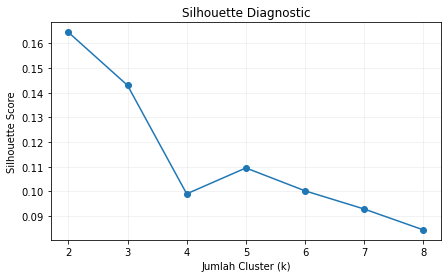

In [8]:
diagnostic = []

for k in range(2, 9):
    km = KMeans(
        n_clusters=k,
        n_init=30,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X_train_pca)

    diagnostic.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(
            X_train_pca,
            labels,
            sample_size=min(1000, len(X_train_pca)),
            random_state=RANDOM_STATE
        )
    })

diagnostic_df = pd.DataFrame(diagnostic)
display(diagnostic_df)

plt.figure(figsize=(7, 4))
plt.plot(diagnostic_df["k"], diagnostic_df["silhouette"], marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Diagnostic")
plt.grid(alpha=0.2)
plt.show()


# Hyperparameter Tuning

In [9]:
# ============================================================
# HYPERPARAMETER TUNING K-MEANS
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import itertools
import pandas as pd


# ------------------------------------------------------------
# PARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    "init": [
        "k-means++",
        "random"
    ],
    
    "n_init": [
        10,
        30,
        50,
        100
    ],
    
    "max_iter": [
        300,
        500,
        1000
    ],
    
    "tol": [
        1e-3,
        1e-4,
        1e-5
    ],
    
    "algorithm": [
        "lloyd",
        "elkan"
    ]
}


# ------------------------------------------------------------
# RUN ALL COMBINATIONS
# ------------------------------------------------------------

tuning_results = []

for init, n_init, max_iter, tol, algorithm in itertools.product(
    param_grid["init"],
    param_grid["n_init"],
    param_grid["max_iter"],
    param_grid["tol"],
    param_grid["algorithm"]
):

    km = KMeans(
        n_clusters=2,              # FIXED karena requirement 2 cluster
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        tol=tol,
        algorithm=algorithm,
        random_state=RANDOM_STATE
    )

    labels = km.fit_predict(X_train_pca)

    # Internal clustering metrics
    silhouette = silhouette_score(
        X_train_pca,
        labels,
        sample_size=min(1000, len(X_train_pca)),
        random_state=RANDOM_STATE
    )

    db_score = davies_bouldin_score(
        X_train_pca,
        labels
    )

    ch_score = calinski_harabasz_score(
        X_train_pca,
        labels
    )

    tuning_results.append({
        "init": init,
        "n_init": n_init,
        "max_iter": max_iter,
        "tol": tol,
        "algorithm": algorithm,
        "silhouette": silhouette,
        "davies_bouldin": db_score,
        "calinski_harabasz": ch_score,
        "inertia": km.inertia_
    })


tuning_df = pd.DataFrame(tuning_results)

display(
    tuning_df.sort_values(
        "silhouette",
        ascending=False
    ).head(20)
)

,init,n_init,max_iter,tol,algorithm,silhouette,davies_bouldin,calinski_harabasz,inertia
72,random,10,300,0.00100,lloyd,0.165335,2.505766,479.184441,106657.863588
99,random,30,500,0.00010,elkan,0.165335,2.505766,479.184441,106657.863588
93,random,30,300,0.00010,elkan,0.165335,2.505766,479.184441,106657.863588
94,random,30,300,0.00001,lloyd,0.165335,2.506035,479.186651,106657.779202
95,random,30,300,0.00001,elkan,0.165335,2.506035,479.186651,106657.779202
96,random,30,500,0.00100,lloyd,0.165335,2.505766,479.184441,106657.863588
97,random,30,500,0.00100,elkan,0.165335,2.505766,479.184441,106657.863588
98,random,30,500,0.00010,lloyd,0.165335,2.505766,479.184441,106657.863588
100,random,30,500,0.00001,lloyd,0.165335,2.506035,479.186651,106657.779202
91,random,30,300,0.00100,elkan,0.165335,2.505766,479.184441,106657.863588


In [10]:
# ============================================================
# RANKING TUNING RESULT
# ============================================================

tuning_df["rank_silhouette"] = tuning_df[
    "silhouette"
].rank(
    ascending=False,
    method="min"
)

tuning_df["rank_davies"] = tuning_df[
    "davies_bouldin"
].rank(
    ascending=True,
    method="min"
)

tuning_df["rank_calinski"] = tuning_df[
    "calinski_harabasz"
].rank(
    ascending=False,
    method="min"
)


# Average rank
tuning_df["average_rank"] = (
    tuning_df[
        [
            "rank_silhouette",
            "rank_davies",
            "rank_calinski"
        ]
    ]
    .mean(axis=1)
)


tuning_df = tuning_df.sort_values(
    [
        "average_rank",
        "silhouette"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(drop=True)


display(
    tuning_df.head(20)
)

,init,n_init,max_iter,tol,algorithm,silhouette,davies_bouldin,calinski_harabasz,inertia,rank_silhouette,rank_davies,rank_calinski,average_rank
0,random,10,300,0.00100,lloyd,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0
1,random,10,300,0.00100,elkan,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0
2,random,10,300,0.00010,lloyd,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0
3,random,10,300,0.00010,elkan,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0
4,random,10,300,0.00001,lloyd,0.165335,2.506035,479.186651,106657.779202,1.0,49.0,1.0,17.0
5,random,10,300,0.00001,elkan,0.165335,2.506035,479.186651,106657.779202,1.0,49.0,1.0,17.0
6,random,10,500,0.00100,lloyd,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0
7,random,10,500,0.00100,elkan,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0
8,random,10,500,0.00010,lloyd,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0
9,random,10,500,0.00010,elkan,0.165335,2.505766,479.184441,106657.863588,1.0,1.0,49.0,17.0


In [11]:
# ============================================================
# GET BEST PARAMETER
# ============================================================

best_row = tuning_df.iloc[0]

best_kmeans_params = {
    "n_clusters": 2,
    "init": best_row["init"],
    "n_init": int(best_row["n_init"]),
    "max_iter": int(best_row["max_iter"]),
    "tol": float(best_row["tol"]),
    "algorithm": best_row["algorithm"],
    "random_state": RANDOM_STATE
}

print("BEST K-MEANS PARAMETERS")
print("=" * 50)

for param, value in best_kmeans_params.items():
    print(f"{param}: {value}")

BEST K-MEANS PARAMETERS
n_clusters: 2
init: random
n_init: 10
max_iter: 300
tol: 0.001
algorithm: lloyd
random_state: 42


# Final K-Means k=2

In [12]:
kmeans = KMeans(
    **best_kmeans_params
)

cluster_train = kmeans.fit_predict(X_train_pca)
cluster_oot = kmeans.predict(X_oot_pca)

print("Train cluster counts:")
display(pd.Series(cluster_train).value_counts().sort_index().to_frame("n"))

print("OOT cluster counts:")
display(pd.Series(cluster_oot).value_counts().sort_index().to_frame("n"))


Train cluster counts:


,n
0,1143
1,2527


OOT cluster counts:


,n
0,158
1,355


# Post-hoc validation terhadap target

**Penting:** target tidak digunakan ketika fit K-Means. Di tahap ini target hanya dipakai untuk melihat cluster mana yang punya default rate lebih tinggi. Cluster tersebut diberi nama `High Risk / Default-like`.


In [13]:
y_train = y.loc[train_mask].astype(int).to_numpy()

train_eval = pd.DataFrame({
    "cluster": cluster_train,
    "actual_default": y_train
})

cluster_default_rate = (
    train_eval.groupby("cluster")["actual_default"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "defaults", "mean": "default_rate"})
)

display(cluster_default_rate)

risk_cluster = cluster_default_rate["default_rate"].idxmax()
safe_cluster = cluster_default_rate["default_rate"].idxmin()

print("High-risk cluster:", risk_cluster)
print("Low-risk cluster :", safe_cluster)


,count,defaults,default_rate
cluster,,,
0,1143,95,0.083115
1,2527,21,0.008310


High-risk cluster: 0
Low-risk cluster : 1


# External validation metrics

In [14]:
pred_default_like_train = (cluster_train == risk_cluster).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_train,
    pred_default_like_train
).ravel()

metrics_train = pd.DataFrame([{
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "accuracy": accuracy_score(y_train, pred_default_like_train),
    "precision": precision_score(y_train, pred_default_like_train, zero_division=0),
    "recall": recall_score(y_train, pred_default_like_train, zero_division=0),
    "f1": f1_score(y_train, pred_default_like_train, zero_division=0),
    "ARI": adjusted_rand_score(y_train, cluster_train),
    "NMI": normalized_mutual_info_score(y_train, cluster_train),
    "silhouette": silhouette_score(
        X_train_pca,
        cluster_train,
        sample_size=min(1000, len(X_train_pca)),
        random_state=RANDOM_STATE
    ),
    "davies_bouldin": davies_bouldin_score(X_train_pca, cluster_train)
}])

display(metrics_train)


,TN,FP,FN,TP,accuracy,precision,recall,f1,ARI,NMI,silhouette,davies_bouldin
0,2506,1048,21,95,0.708719,0.083115,0.818966,0.150913,0.056475,0.047357,0.165335,2.505766


# OOT validation

In [15]:
y_oot = y.loc[oot_mask].to_numpy()
valid_oot = ~np.isnan(y_oot)

oot_eval = pd.DataFrame({
    "cluster": cluster_oot[valid_oot],
    "actual_default": y_oot[valid_oot].astype(int)
})

display(
    oot_eval.groupby("cluster")["actual_default"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "defaults", "mean": "default_rate"})
)

pred_default_like_oot = (cluster_oot == risk_cluster).astype(int)

cm_oot = confusion_matrix(
    y_oot[valid_oot].astype(int),
    pred_default_like_oot[valid_oot]
)

print("OOT confusion matrix:")
print(cm_oot)

print("OOT precision:",
      precision_score(y_oot[valid_oot], pred_default_like_oot[valid_oot], zero_division=0))
print("OOT recall:",
      recall_score(y_oot[valid_oot], pred_default_like_oot[valid_oot], zero_division=0))
print("OOT f1:",
      f1_score(y_oot[valid_oot], pred_default_like_oot[valid_oot], zero_division=0))


,count,defaults,default_rate
cluster,,,
0,116,6,0.051724
1,263,7,0.026616


OOT confusion matrix:
[[256 110]
 [  7   6]]
OOT precision: 0.05172413793103448
OOT recall: 0.46153846153846156
OOT f1: 0.09302325581395349


# Visualisasi PCA 2D

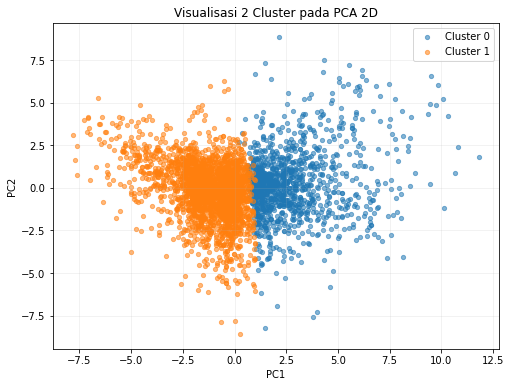

In [16]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))

for k in sorted(np.unique(cluster_train)):
    mask = cluster_train == k
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=18,
        alpha=0.55,
        label=f"Cluster {k}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisasi 2 Cluster pada PCA 2D")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# Visualisasi ukuran cluster dan actual default rate

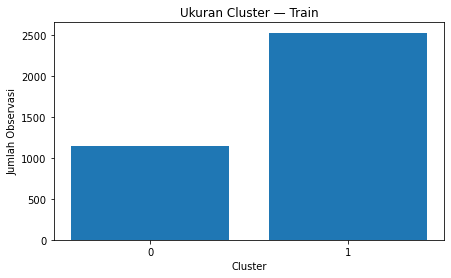

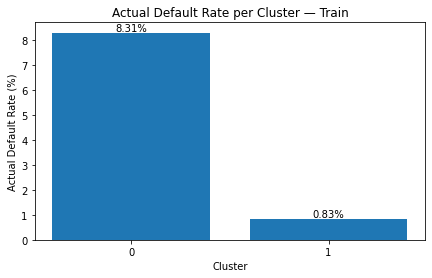

In [17]:
cluster_size = pd.Series(cluster_train).value_counts().sort_index()
dr = train_eval.groupby("cluster")["actual_default"].mean().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(cluster_size.index.astype(str), cluster_size.values)
plt.xlabel("Cluster")
plt.ylabel("Jumlah Observasi")
plt.title("Ukuran Cluster — Train")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(dr.index.astype(str), dr.values * 100)
plt.xlabel("Cluster")
plt.ylabel("Actual Default Rate (%)")
plt.title("Actual Default Rate per Cluster — Train")

for i, v in enumerate(dr.values * 100):
    plt.text(i, v, f"{v:.2f}%", ha="center", va="bottom")

plt.show()


# Profiling karakteristik cluster

In [18]:
profile = data.loc[train_mask, risk_features].copy()
profile["cluster"] = cluster_train
profile["cluster_segment"] = np.where(
    profile["cluster"].eq(risk_cluster),
    "High Risk / Default-like",
    "Low Risk / Non-default-like"
)

profile["app_rating_internal_num"] = profile["app_rating_internal"].map(rating_map)

important_features = [
    "app_skor_kredit",
    "app_pricing_bps",
    "app_rating_internal_num",
    "fin_debt_to_ebitda",
    "fin_der",
    "fin_icr",
    "fin_roa",
    "fin_wc_to_ta",
    "fin_cfo_to_liability"
]

rows = []

for c in important_features:
    s = pd.to_numeric(profile[c], errors="coerce")

    for segment in profile["cluster_segment"].unique():
        mask = profile["cluster_segment"].eq(segment)

        rows.append({
            "feature": c,
            "cluster_segment": segment,
            "median": s[mask].median(),
            "mean": s[mask].mean()
        })

cluster_profile = pd.DataFrame(rows)

display(
    cluster_profile.pivot(
        index="feature",
        columns="cluster_segment",
        values="median"
    )
)


cluster_segment,High Risk / Default-like,Low Risk / Non-default-like
feature,,
app_pricing_bps,872.000000,747.000000
app_rating_internal_num,5.000000,4.000000
app_skor_kredit,23.490000,74.570000
fin_cfo_to_liability,-0.152150,0.214115
fin_debt_to_ebitda,9.061645,2.735927
fin_der,2.026718,0.709929
fin_icr,-0.723988,4.151098
fin_roa,-0.163629,0.053838
fin_wc_to_ta,0.132965,0.258127


# Save hasil cluster ke CSV

In [32]:
result = df.copy()

result["cluster_id"] = np.nan
result.loc[train_mask, "cluster_id"] = cluster_train
result.loc[oot_mask, "cluster_id"] = cluster_oot
result["cluster_id"] = result["cluster_id"].astype(int)

result["cluster_segment"] = np.where(
    result["cluster_id"].eq(risk_cluster),
    "High Risk / Default-like",
    "Low Risk / Non-default-like"
)

result.to_csv("abt_pd_clustered.csv", index=False)

display(
    result[
        [
            "application_id",
            "split",
            "y_default_12bln",
            "cluster_id",
            "cluster_segment"
        ]
    ].head()
)

print("Saved: abt_pd_clustered.csv")


,application_id,split,y_default_12bln,cluster_id,cluster_segment
0,1,latih,0.0,1,High Risk / Default-like
1,2,latih,0.0,0,Low Risk / Non-default-like
2,3,latih,0.0,0,Low Risk / Non-default-like
3,4,latih,0.0,0,Low Risk / Non-default-like
4,5,latih,0.0,0,Low Risk / Non-default-like


Saved: abt_pd_clustered.csv


# Save File ke GitHub

In [19]:
# ============================================================
# PD CLUSTERING - ONE CELL PRODUCTION ARTIFACT EXPORT
# ============================================================
# Jalankan SETELAH seluruh notebook clustering selesai.
#
# Output:
#
# ml/artifacts/pd_cluster/
# ├── pd_cluster_champion.joblib
# ├── pd_cluster_metadata.json
# ├── pd_cluster_feature_schema.json
# ├── pd_cluster_metrics.json
# ├── pd_cluster_profiles.json
# ├── pd_cluster_profile.csv
# ├── pd_cluster_summary.csv
# ├── pd_cluster_diagnostic.csv
# ├── pd_cluster_reference_stats.json
# ├── pd_cluster_requirements.txt
# └── pd_cluster_manifest.json
#
# ml/inference/
# └── pd_cluster_predictor.py
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

from pathlib import Path

import sys
import json
import hashlib
import joblib
import importlib
import importlib.metadata

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)


print("=" * 80)
print("PD CLUSTERING PRODUCTION ARTIFACT EXPORT")
print("=" * 80)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "df",
    "data",
    "y",
    "train_mask",
    "oot_mask",
    "risk_features",
    "X_train",
    "X_oot",
    "clip_bounds",
    "imputer",
    "scaler",
    "pca",
    "X_train_pca",
    "X_oot_pca",
    "kmeans",
    "cluster_train",
    "cluster_oot",
    "risk_cluster",
    "safe_cluster",
    "rating_map"
]


missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]


if missing_variables:

    raise NameError(
        "Variable berikut belum tersedia.\n"
        "Jalankan seluruh notebook clustering terlebih dahulu:\n\n"
        + "\n".join(
            f"- {var}"
            for var in missing_variables
        )
    )


print("✅ Required modeling variables tersedia")


# ============================================================
# 2. CONFIGURATION
# ============================================================

MODEL_NAME = "PD_RISK_CLUSTERING_KMEANS"
MODEL_VERSION = "1.0.0"

RANDOM_STATE_EXPORT = globals().get(
    "RANDOM_STATE",
    42
)


CLUSTER_SEGMENTS = {
    int(risk_cluster):
        "High Risk / Default-like",

    int(safe_cluster):
        "Low Risk / Non-default-like"
}


print(
    "✅ High-risk cluster:",
    int(risk_cluster)
)

print(
    "✅ Low-risk cluster :",
    int(safe_cluster)
)

print(
    "✅ Number of features:",
    len(risk_features)
)


# ============================================================
# 3. DIRECTORY
# ============================================================

CURRENT_DIR = Path.cwd().resolve()


# Jika notebook berada di ml/notebooks/
if CURRENT_DIR.name == "notebooks":

    ML_ROOT = CURRENT_DIR.parent


# Jika notebook dijalankan dari folder ml/
elif CURRENT_DIR.name == "ml":

    ML_ROOT = CURRENT_DIR


# Jika notebook dijalankan dari root repo
elif (
    CURRENT_DIR
    / "ml"
).exists():

    ML_ROOT = (
        CURRENT_DIR
        / "ml"
    )


# Fallback
else:

    ML_ROOT = (
        Path("..")
        .resolve()
    )


ARTIFACT_DIR = (
    ML_ROOT
    / "artifacts"
    / "pd_cluster"
)


INFERENCE_DIR = (
    ML_ROOT
    / "inference"
)


ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "ML Root       :",
    ML_ROOT
)

print(
    "Artifact Dir  :",
    ARTIFACT_DIR
)

print(
    "Inference Dir :",
    INFERENCE_DIR
)


# ============================================================
# 4. HELPER
# ============================================================

def safe_float(value):

    if value is None:
        return None

    try:

        if pd.isna(value):
            return None

    except Exception:

        pass

    return float(value)


def json_safe(value):

    if isinstance(
        value,
        dict
    ):

        return {
            str(k): json_safe(v)
            for k, v in value.items()
        }


    if isinstance(
        value,
        (list, tuple)
    ):

        return [
            json_safe(v)
            for v in value
        ]


    if isinstance(
        value,
        (
            np.integer,
            np.int32,
            np.int64
        )
    ):

        return int(value)


    if isinstance(
        value,
        (
            np.floating,
            np.float32,
            np.float64
        )
    ):

        return float(value)


    if isinstance(
        value,
        np.bool_
    ):

        return bool(value)


    return value


def sha256_file(path):

    sha256 = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            sha256.update(
                chunk
            )

    return sha256.hexdigest()


# ============================================================
# 5. REBUILD TARGET VALIDATION
# ============================================================

y_train_export = (
    pd.to_numeric(
        y.loc[
            train_mask
        ],
        errors="coerce"
    )
    .to_numpy()
)


valid_train = (
    ~np.isnan(
        y_train_export
    )
)


y_oot_export = (
    pd.to_numeric(
        y.loc[
            oot_mask
        ],
        errors="coerce"
    )
    .to_numpy()
)


valid_oot = (
    ~np.isnan(
        y_oot_export
    )
)


print(
    "Train labeled:",
    int(
        valid_train.sum()
    )
)

print(
    "OOT labeled:",
    int(
        valid_oot.sum()
    )
)


# ============================================================
# 6. TRAIN CLUSTER VALIDATION
# ============================================================

train_actual = (
    y_train_export[
        valid_train
    ]
    .astype(int)
)


train_cluster_valid = (
    np.asarray(
        cluster_train
    )[
        valid_train
    ]
)


train_default_like = (
    train_cluster_valid
    ==
    risk_cluster
).astype(int)


tn, fp, fn, tp = (
    confusion_matrix(
        train_actual,
        train_default_like,
        labels=[0, 1]
    )
    .ravel()
)


train_metrics = {

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "accuracy":
        float(
            accuracy_score(
                train_actual,
                train_default_like
            )
        ),

    "precision":
        float(
            precision_score(
                train_actual,
                train_default_like,
                zero_division=0
            )
        ),

    "recall":
        float(
            recall_score(
                train_actual,
                train_default_like,
                zero_division=0
            )
        ),

    "f1":
        float(
            f1_score(
                train_actual,
                train_default_like,
                zero_division=0
            )
        ),

    "ARI":
        float(
            adjusted_rand_score(
                train_actual,
                train_cluster_valid
            )
        ),

    "NMI":
        float(
            normalized_mutual_info_score(
                train_actual,
                train_cluster_valid
            )
        ),

    "silhouette":
        float(
            silhouette_score(
                X_train_pca,
                cluster_train,
                sample_size=min(
                    1000,
                    len(
                        X_train_pca
                    )
                ),
                random_state=
                    RANDOM_STATE_EXPORT
            )
        ),

    "davies_bouldin":
        float(
            davies_bouldin_score(
                X_train_pca,
                cluster_train
            )
        ),

    "inertia":
        float(
            kmeans.inertia_
        )
}


print(
    "\nTRAIN VALIDATION"
)

display(
    pd.DataFrame([
        train_metrics
    ])
)


# ============================================================
# 7. OOT VALIDATION
# ============================================================

oot_actual = (
    y_oot_export[
        valid_oot
    ]
    .astype(int)
)


oot_cluster_valid = (
    np.asarray(
        cluster_oot
    )[
        valid_oot
    ]
)


oot_default_like = (
    oot_cluster_valid
    ==
    risk_cluster
).astype(int)


tn, fp, fn, tp = (
    confusion_matrix(
        oot_actual,
        oot_default_like,
        labels=[0, 1]
    )
    .ravel()
)


oot_metrics = {

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "accuracy":
        float(
            accuracy_score(
                oot_actual,
                oot_default_like
            )
        ),

    "precision":
        float(
            precision_score(
                oot_actual,
                oot_default_like,
                zero_division=0
            )
        ),

    "recall":
        float(
            recall_score(
                oot_actual,
                oot_default_like,
                zero_division=0
            )
        ),

    "f1":
        float(
            f1_score(
                oot_actual,
                oot_default_like,
                zero_division=0
            )
        ),

    "ARI":
        float(
            adjusted_rand_score(
                oot_actual,
                oot_cluster_valid
            )
        ),

    "NMI":
        float(
            normalized_mutual_info_score(
                oot_actual,
                oot_cluster_valid
            )
        ),

    "silhouette":
        float(
            silhouette_score(
                X_oot_pca,
                cluster_oot,
                sample_size=min(
                    1000,
                    len(
                        X_oot_pca
                    )
                ),
                random_state=
                    RANDOM_STATE_EXPORT
            )
        ),

    "davies_bouldin":
        float(
            davies_bouldin_score(
                X_oot_pca,
                cluster_oot
            )
        )
}


print(
    "\nOOT VALIDATION"
)

display(
    pd.DataFrame([
        oot_metrics
    ])
)


# ============================================================
# 8. CLUSTER SUMMARY
# ============================================================

train_summary_base = pd.DataFrame({

    "cluster_id":
        np.asarray(
            cluster_train
        ),

    "actual_default":
        y_train_export
})


train_summary = (
    train_summary_base
    .groupby(
        "cluster_id"
    )
    .agg(

        n=(
            "cluster_id",
            "size"
        ),

        n_labeled=(
            "actual_default",
            "count"
        ),

        actual_defaults=(
            "actual_default",
            "sum"
        ),

        default_rate=(
            "actual_default",
            "mean"
        )
    )
    .reset_index()
)


train_summary[
    "split"
] = "latih"


oot_summary_base = pd.DataFrame({

    "cluster_id":
        np.asarray(
            cluster_oot
        ),

    "actual_default":
        y_oot_export
})


oot_summary = (
    oot_summary_base
    .groupby(
        "cluster_id"
    )
    .agg(

        n=(
            "cluster_id",
            "size"
        ),

        n_labeled=(
            "actual_default",
            "count"
        ),

        actual_defaults=(
            "actual_default",
            "sum"
        ),

        default_rate=(
            "actual_default",
            "mean"
        )
    )
    .reset_index()
)


oot_summary[
    "split"
] = "uji_oot"


cluster_summary = pd.concat(
    [
        train_summary,
        oot_summary
    ],
    ignore_index=True
)


cluster_summary[
    "cluster_segment"
] = (
    cluster_summary[
        "cluster_id"
    ]
    .map(
        CLUSTER_SEGMENTS
    )
)


cluster_summary = (
    cluster_summary[
        [
            "split",
            "cluster_id",
            "cluster_segment",
            "n",
            "n_labeled",
            "actual_defaults",
            "default_rate"
        ]
    ]
)


CLUSTER_SUMMARY_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_summary.csv"
)


cluster_summary.to_csv(
    CLUSTER_SUMMARY_PATH,
    index=False
)


print(
    "✅ Saved:",
    CLUSTER_SUMMARY_PATH
)


display(
    cluster_summary
)


# ============================================================
# 9. CLUSTER PROFILE
# ============================================================

if "cluster_profile" in globals():

    cluster_profile_export = (
        cluster_profile.copy()
    )

else:

    profile_source = (
        data.loc[
            train_mask,
            risk_features
        ]
        .copy()
    )


    profile_source[
        "cluster_id"
    ] = cluster_train


    profile_source[
        "cluster_segment"
    ] = (
        profile_source[
            "cluster_id"
        ]
        .map(
            CLUSTER_SEGMENTS
        )
    )


    profile_source[
        "app_rating_internal_num"
    ] = (
        profile_source[
            "app_rating_internal"
        ]
        .map(
            rating_map
        )
    )


    important_features_export = [
        "app_skor_kredit",
        "app_pricing_bps",
        "app_rating_internal_num",
        "fin_debt_to_ebitda",
        "fin_der",
        "fin_icr",
        "fin_roa",
        "fin_wc_to_ta",
        "fin_cfo_to_liability"
    ]


    important_features_export = [

        c
        for c
        in important_features_export

        if c
        in profile_source.columns
    ]


    profile_rows = []


    for feature in (
        important_features_export
    ):

        values = pd.to_numeric(
            profile_source[
                feature
            ],
            errors="coerce"
        )


        for cluster_id in sorted(
            CLUSTER_SEGMENTS
        ):

            mask = (
                profile_source[
                    "cluster_id"
                ]
                ==
                cluster_id
            )


            profile_rows.append({

                "feature":
                    feature,

                "cluster_id":
                    int(
                        cluster_id
                    ),

                "cluster_segment":
                    CLUSTER_SEGMENTS[
                        cluster_id
                    ],

                "median":
                    safe_float(
                        values[
                            mask
                        ].median()
                    ),

                "mean":
                    safe_float(
                        values[
                            mask
                        ].mean()
                    )
            })


    cluster_profile_export = (
        pd.DataFrame(
            profile_rows
        )
    )


CLUSTER_PROFILE_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_profile.csv"
)


cluster_profile_export.to_csv(
    CLUSTER_PROFILE_PATH,
    index=False
)


print(
    "✅ Saved:",
    CLUSTER_PROFILE_PATH
)


# ============================================================
# 10. CLUSTER PROFILES JSON
# ============================================================

cluster_profiles_json = {}


for cluster_id in sorted(
    CLUSTER_SEGMENTS
):

    cluster_id_int = int(
        cluster_id
    )


    segment_name = (
        CLUSTER_SEGMENTS[
            cluster_id_int
        ]
    )


    train_row = (
        train_summary[
            train_summary[
                "cluster_id"
            ]
            ==
            cluster_id_int
        ]
    )


    if len(train_row):

        train_dr = safe_float(
            train_row.iloc[0][
                "default_rate"
            ]
        )

        train_n = int(
            train_row.iloc[0][
                "n"
            ]
        )

    else:

        train_dr = None
        train_n = 0


    profile_records = []


    if (
        "cluster_segment"
        in cluster_profile_export.columns
    ):

        sub_profile = (
            cluster_profile_export[
                cluster_profile_export[
                    "cluster_segment"
                ]
                ==
                segment_name
            ]
        )


        for _, row in (
            sub_profile.iterrows()
        ):

            profile_records.append({

                "feature":
                    str(
                        row[
                            "feature"
                        ]
                    ),

                "median":
                    safe_float(
                        row[
                            "median"
                        ]
                    ),

                "mean":
                    safe_float(
                        row[
                            "mean"
                        ]
                    )
            })


    cluster_profiles_json[
        str(
            cluster_id_int
        )
    ] = {

        "cluster_id":
            cluster_id_int,

        "segment":
            segment_name,

        "description":
            (
                "Higher-risk financial and underwriting profile; "
                "empirically associated with higher observed default rate."
                if cluster_id_int
                ==
                int(
                    risk_cluster
                )
                else
                "Relatively healthier financial and underwriting profile; "
                "empirically associated with lower observed default rate."
            ),

        "training_n":
            train_n,

        "training_default_rate":
            train_dr,

        "profile":
            profile_records
    }


CLUSTER_PROFILES_JSON_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_profiles.json"
)


with open(
    CLUSTER_PROFILES_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            cluster_profiles_json
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    CLUSTER_PROFILES_JSON_PATH
)


# ============================================================
# 11. DIAGNOSTIC K
# ============================================================

DIAGNOSTIC_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_diagnostic.csv"
)


if "diagnostic_df" in globals():

    diagnostic_export = (
        diagnostic_df.copy()
    )

else:

    diagnostic_export = (
        pd.DataFrame()
    )


diagnostic_export.to_csv(
    DIAGNOSTIC_PATH,
    index=False
)


print(
    "✅ Saved:",
    DIAGNOSTIC_PATH
)


# ============================================================
# 12. FINAL PRODUCTION REFIT — TRAIN + OOT
# ============================================================
#
# PENTING:
# Metric TRAIN/OOT di atas berasal dari model development
# (fit TRAIN saja), sehingga OOT masih valid untuk evaluasi.
#
# Setelah evaluasi selesai, BARU seluruh pipeline clustering
# di-fit ulang menggunakan seluruh populasi TRAIN + OOT:
#
#   raw data
#      -> rating encoding
#      -> final clip bounds 1%-99%
#      -> final imputer
#      -> final scaler
#      -> final PCA
#      -> final KMeans
#
# y_default TIDAK dipakai saat fitting.
# y hanya digunakan POST-HOC untuk memberi nama cluster.
# ============================================================


FINAL_FIT_MASK = (
    np.asarray(
        train_mask
    ).astype(bool)
    |
    np.asarray(
        oot_mask
    ).astype(bool)
)


final_raw = (
    data.loc[
        FINAL_FIT_MASK,
        risk_features
    ]
    .copy()
)


final_y = (
    pd.to_numeric(
        y.loc[
            FINAL_FIT_MASK
        ],
        errors="coerce"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nFINAL REFIT POPULATION"
)

print(
    "Train rows     :",
    int(
        np.asarray(
            train_mask
        ).sum()
    )
)

print(
    "OOT rows       :",
    int(
        np.asarray(
            oot_mask
        ).sum()
    )
)

print(
    "Final fit rows :",
    int(
        len(
            final_raw
        )
    )
)


# ============================================================
# 12A. RAW -> NUMERIC
# ============================================================

final_numeric = (
    final_raw
    .copy()
    .replace(
        "\\N",
        np.nan
    )
)


if (
    "app_rating_internal"
    in final_numeric.columns
):

    original_rating = (
        final_numeric[
            "app_rating_internal"
        ]
        .copy()
    )

    numeric_rating = (
        pd.to_numeric(
            original_rating,
            errors="coerce"
        )
    )

    mapped_rating = (
        original_rating
        .astype(str)
        .map(
            rating_map
        )
    )

    final_numeric[
        "app_rating_internal"
    ] = (
        numeric_rating
        .where(
            numeric_rating.notna(),
            mapped_rating
        )
    )


for feature in risk_features:

    final_numeric[
        feature
    ] = (
        pd.to_numeric(
            final_numeric[
                feature
            ],
            errors="coerce"
        )
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .astype(float)
    )


# ============================================================
# 12B. RECALCULATE FINAL CLIP BOUNDS
# ============================================================

FINAL_CLIP_BOUNDS = {}


for feature in risk_features:

    clean = (
        final_numeric[
            feature
        ]
        .dropna()
        .astype(float)
    )

    if len(clean) == 0:

        raise ValueError(
            f"Feature {feature} seluruhnya missing "
            "pada TRAIN + OOT."
        )

    FINAL_CLIP_BOUNDS[
        feature
    ] = (
        float(
            clean.quantile(
                0.01
            )
        ),
        float(
            clean.quantile(
                0.99
            )
        )
    )


final_clipped = (
    final_numeric
    .copy()
)


for feature in risk_features:

    lo, hi = (
        FINAL_CLIP_BOUNDS[
            feature
        ]
    )

    final_clipped[
        feature
    ] = (
        final_clipped[
            feature
        ]
        .clip(
            lo,
            hi
        )
    )


# ============================================================
# 12C. REFIT ALL LEARNED PREPROCESSING + KMEANS
# ============================================================

FINAL_IMPUTER = clone(
    imputer
)

FINAL_SCALER = clone(
    scaler
)

FINAL_PCA = clone(
    pca
)

FINAL_KMEANS = clone(
    kmeans
)


X_final_imp = (
    FINAL_IMPUTER
    .fit_transform(
        final_clipped
    )
)


X_final_scaled = (
    FINAL_SCALER
    .fit_transform(
        X_final_imp
    )
)


X_final_pca = (
    FINAL_PCA
    .fit_transform(
        X_final_scaled
    )
)


FINAL_CLUSTER_ALL = (
    FINAL_KMEANS
    .fit_predict(
        X_final_pca
    )
)


print(
    "✅ Final imputer fitted on TRAIN + OOT"
)

print(
    "✅ Final scaler fitted on TRAIN + OOT"
)

print(
    "✅ Final PCA fitted on TRAIN + OOT"
)

print(
    "✅ Final KMeans fitted on TRAIN + OOT"
)


# ============================================================
# 12D. RE-IDENTIFY FINAL RISK CLUSTER
# ============================================================
#
# Cluster ID KMeans dapat bertukar setelah refit.
# Karena itu jangan memakai risk_cluster / safe_cluster lama.
#
# Target tetap TIDAK digunakan untuk training.
# Hanya digunakan sesudah fit untuk interpretasi cluster.
# ============================================================

final_cluster_label_df = (
    pd.DataFrame({

        "cluster_id":
            np.asarray(
                FINAL_CLUSTER_ALL
            )
            .astype(int),

        "actual_default":
            final_y
            .to_numpy()
    })
)


final_cluster_default_rates = (
    final_cluster_label_df
    .dropna(
        subset=[
            "actual_default"
        ]
    )
    .groupby(
        "cluster_id"
    )[
        "actual_default"
    ]
    .mean()
)


if len(
    final_cluster_default_rates
) < 2:

    raise ValueError(
        "Tidak cukup labeled rows untuk menentukan "
        "high-risk dan low-risk cluster."
    )


FINAL_RISK_CLUSTER = int(
    final_cluster_default_rates
    .idxmax()
)


final_cluster_ids = sorted(
    np.unique(
        FINAL_CLUSTER_ALL
    )
    .astype(int)
    .tolist()
)


safe_candidates = [
    cid
    for cid in final_cluster_ids
    if cid != FINAL_RISK_CLUSTER
]


if len(
    safe_candidates
) != 1:

    raise ValueError(
        "Exporter ini mengharapkan KMeans dengan k=2."
    )


FINAL_SAFE_CLUSTER = int(
    safe_candidates[0]
)


FINAL_CLUSTER_SEGMENTS = {

    FINAL_RISK_CLUSTER:
        "High Risk / Default-like",

    FINAL_SAFE_CLUSTER:
        "Low Risk / Non-default-like"
}


print(
    "\nFINAL CLUSTER MAPPING"
)

print(
    "High-risk cluster:",
    FINAL_RISK_CLUSTER
)

print(
    "Low-risk cluster :",
    FINAL_SAFE_CLUSTER
)

display(
    final_cluster_default_rates
    .rename(
        "default_rate"
    )
    .to_frame()
)


# ============================================================
# 12E. FINAL PRODUCTION CLUSTER METRICS
# ============================================================

FINAL_SILHOUETTE = float(
    silhouette_score(
        X_final_pca,
        FINAL_CLUSTER_ALL,
        sample_size=min(
            1000,
            len(
                X_final_pca
            )
        ),
        random_state=
            RANDOM_STATE_EXPORT
    )
)


FINAL_DAVIES_BOULDIN = float(
    davies_bouldin_score(
        X_final_pca,
        FINAL_CLUSTER_ALL
    )
)


FINAL_INERTIA = float(
    FINAL_KMEANS.inertia_
)


print(
    "\nFINAL PRODUCTION METRICS"
)

display(
    pd.DataFrame([{
        "rows":
            int(
                len(
                    final_raw
                )
            ),

        "silhouette":
            FINAL_SILHOUETTE,

        "davies_bouldin":
            FINAL_DAVIES_BOULDIN,

        "inertia":
            FINAL_INERTIA,

        "pca_components":
            int(
                FINAL_PCA.n_components_
            ),

        "pca_explained_variance":
            float(
                FINAL_PCA
                .explained_variance_ratio_
                .sum()
            )
    }])
)


# ============================================================
# 13. REBUILD FINAL CLUSTER SUMMARY
# ============================================================

final_summary = (
    final_cluster_label_df
    .groupby(
        "cluster_id"
    )
    .agg(

        n=(
            "cluster_id",
            "size"
        ),

        n_labeled=(
            "actual_default",
            "count"
        ),

        actual_defaults=(
            "actual_default",
            "sum"
        ),

        default_rate=(
            "actual_default",
            "mean"
        )
    )
    .reset_index()
)


final_summary[
    "split"
] = "production_refit_train_plus_oot"


final_summary[
    "cluster_segment"
] = (
    final_summary[
        "cluster_id"
    ]
    .map(
        FINAL_CLUSTER_SEGMENTS
    )
)


# Tambahkan summary development lama untuk audit
train_summary[
    "split"
] = "development_train"


oot_summary[
    "split"
] = "development_oot"


cluster_summary = pd.concat(
    [
        train_summary,
        oot_summary,
        final_summary
    ],
    ignore_index=True
)


cluster_summary[
    "cluster_segment"
] = (
    cluster_summary
    .apply(
        lambda row:
            (
                FINAL_CLUSTER_SEGMENTS.get(
                    int(
                        row[
                            "cluster_id"
                        ]
                    )
                )
                if row[
                    "split"
                ]
                ==
                "production_refit_train_plus_oot"
                else
                CLUSTER_SEGMENTS.get(
                    int(
                        row[
                            "cluster_id"
                        ]
                    )
                )
            ),
        axis=1
    )
)


cluster_summary = (
    cluster_summary[
        [
            "split",
            "cluster_id",
            "cluster_segment",
            "n",
            "n_labeled",
            "actual_defaults",
            "default_rate"
        ]
    ]
)


CLUSTER_SUMMARY_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_summary.csv"
)


cluster_summary.to_csv(
    CLUSTER_SUMMARY_PATH,
    index=False
)


print(
    "✅ Re-saved:",
    CLUSTER_SUMMARY_PATH
)


# ============================================================
# 14. REBUILD FINAL PRODUCTION CLUSTER PROFILE
# ============================================================

profile_source = (
    final_raw
    .reset_index(
        drop=True
    )
    .copy()
)


profile_source[
    "cluster_id"
] = (
    FINAL_CLUSTER_ALL
)


profile_source[
    "cluster_segment"
] = (
    profile_source[
        "cluster_id"
    ]
    .map(
        FINAL_CLUSTER_SEGMENTS
    )
)


if (
    "app_rating_internal"
    in profile_source.columns
):

    raw_rating = (
        profile_source[
            "app_rating_internal"
        ]
        .copy()
    )

    rating_numeric = (
        pd.to_numeric(
            raw_rating,
            errors="coerce"
        )
    )

    profile_source[
        "app_rating_internal_num"
    ] = (
        rating_numeric
        .where(
            rating_numeric.notna(),
            raw_rating
            .astype(str)
            .map(
                rating_map
            )
        )
    )


important_features_export = [
    "app_skor_kredit",
    "app_pricing_bps",
    "app_rating_internal_num",
    "fin_debt_to_ebitda",
    "fin_der",
    "fin_icr",
    "fin_roa",
    "fin_wc_to_ta",
    "fin_cfo_to_liability"
]


important_features_export = [
    feature
    for feature
    in important_features_export
    if feature
    in profile_source.columns
]


profile_rows = []


for feature in important_features_export:

    values = (
        pd.to_numeric(
            profile_source[
                feature
            ],
            errors="coerce"
        )
    )

    for cluster_id in sorted(
        FINAL_CLUSTER_SEGMENTS
    ):

        mask = (
            profile_source[
                "cluster_id"
            ]
            ==
            cluster_id
        )

        profile_rows.append({

            "feature":
                feature,

            "cluster_id":
                int(
                    cluster_id
                ),

            "cluster_segment":
                FINAL_CLUSTER_SEGMENTS[
                    cluster_id
                ],

            "median":
                safe_float(
                    values[
                        mask
                    ]
                    .median()
                ),

            "mean":
                safe_float(
                    values[
                        mask
                    ]
                    .mean()
                )
        })


cluster_profile_export = (
    pd.DataFrame(
        profile_rows
    )
)


CLUSTER_PROFILE_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_profile.csv"
)


cluster_profile_export.to_csv(
    CLUSTER_PROFILE_PATH,
    index=False
)


print(
    "✅ Re-saved:",
    CLUSTER_PROFILE_PATH
)


# ============================================================
# 15. REBUILD FINAL CLUSTER PROFILES JSON
# ============================================================

cluster_profiles_json = {}


for cluster_id in sorted(
    FINAL_CLUSTER_SEGMENTS
):

    cluster_id_int = int(
        cluster_id
    )

    segment_name = (
        FINAL_CLUSTER_SEGMENTS[
            cluster_id_int
        ]
    )


    summary_row = (
        final_summary[
            final_summary[
                "cluster_id"
            ]
            ==
            cluster_id_int
        ]
    )


    if len(
        summary_row
    ):

        final_dr = safe_float(
            summary_row
            .iloc[0][
                "default_rate"
            ]
        )

        final_n = int(
            summary_row
            .iloc[0][
                "n"
            ]
        )

    else:

        final_dr = None
        final_n = 0


    sub_profile = (
        cluster_profile_export[
            cluster_profile_export[
                "cluster_id"
            ]
            ==
            cluster_id_int
        ]
    )


    profile_records = []


    for _, row in (
        sub_profile
        .iterrows()
    ):

        profile_records.append({

            "feature":
                str(
                    row[
                        "feature"
                    ]
                ),

            "median":
                safe_float(
                    row[
                        "median"
                    ]
                ),

            "mean":
                safe_float(
                    row[
                        "mean"
                    ]
                )
        })


    cluster_profiles_json[
        str(
            cluster_id_int
        )
    ] = {

        "cluster_id":
            cluster_id_int,

        "segment":
            segment_name,

        "description":
            (
                "Higher-risk financial and underwriting profile; "
                "empirically associated with higher observed default rate."
                if cluster_id_int
                ==
                FINAL_RISK_CLUSTER
                else
                "Relatively healthier financial and underwriting profile; "
                "empirically associated with lower observed default rate."
            ),

        "production_fit_n":
            final_n,

        "production_default_rate":
            final_dr,

        "profile":
            profile_records
    }


CLUSTER_PROFILES_JSON_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_profiles.json"
)


with open(
    CLUSTER_PROFILES_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            cluster_profiles_json
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Re-saved:",
    CLUSTER_PROFILES_JSON_PATH
)


# ============================================================
# 16. FINAL FEATURE SCHEMA
# ============================================================

feature_schema = {

    "model":
        MODEL_NAME,

    "model_version":
        MODEL_VERSION,

    "number_of_features":
        int(
            len(
                risk_features
            )
        ),

    "final_refit_population":
        "train_plus_oot",

    "preprocessing": {

        "special_missing_value":
            "\\N -> NaN",

        "rating_encoding":
            rating_map,

        "winsorization":
            (
                "1st-99th percentile based on "
                "final TRAIN + OOT population"
            ),

        "imputation":
            "median",

        "scaling":
            "StandardScaler",

        "dimensionality_reduction":
            "PCA retaining original configured variance",

        "clustering":
            (
                f"KMeans k="
                f"{int(FINAL_KMEANS.n_clusters)}"
            )
    },

    "features": {}
}


for feature in risk_features:

    original_series = (
        final_raw[
            feature
        ]
    )

    lo, hi = (
        FINAL_CLIP_BOUNDS[
            feature
        ]
    )

    feature_info = {

        "model_dtype":
            "float",

        "nullable":
            bool(
                original_series
                .isna()
                .any()
            ),

        "clip_lower":
            safe_float(
                lo
            ),

        "clip_upper":
            safe_float(
                hi
            )
    }


    if (
        feature
        ==
        "app_rating_internal"
    ):

        feature_info[
            "input_type"
        ] = "ordinal_categorical"

        feature_info[
            "mapping"
        ] = rating_map

    else:

        feature_info[
            "input_type"
        ] = "numeric"


    feature_schema[
        "features"
    ][feature] = feature_info


FEATURE_SCHEMA_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_feature_schema.json"
)


with open(
    FEATURE_SCHEMA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            feature_schema
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Re-saved:",
    FEATURE_SCHEMA_PATH
)


# ============================================================
# 17. FINAL REFERENCE STATISTICS
# ============================================================

reference_stats = {}


for feature in risk_features:

    numeric_series = (
        final_numeric[
            feature
        ]
    )

    clean = (
        numeric_series
        .dropna()
        .astype(float)
    )


    reference_stats[
        feature
    ] = {

        "count":
            int(
                len(
                    clean
                )
            ),

        "missing_count":
            int(
                numeric_series
                .isna()
                .sum()
            ),

        "mean":
            safe_float(
                clean.mean()
            )
            if len(clean)
            else None,

        "median":
            safe_float(
                clean.median()
            )
            if len(clean)
            else None,

        "p25":
            safe_float(
                clean.quantile(
                    0.25
                )
            )
            if len(clean)
            else None,

        "p75":
            safe_float(
                clean.quantile(
                    0.75
                )
            )
            if len(clean)
            else None,

        "p95":
            safe_float(
                clean.quantile(
                    0.95
                )
            )
            if len(clean)
            else None,

        "min":
            safe_float(
                clean.min()
            )
            if len(clean)
            else None,

        "max":
            safe_float(
                clean.max()
            )
            if len(clean)
            else None
    }


REFERENCE_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_reference_stats.json"
)


with open(
    REFERENCE_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        reference_stats,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Re-saved:",
    REFERENCE_PATH
)


# ============================================================
# 18. METRICS
# ============================================================

metrics = {

    "model":
        MODEL_NAME,

    "model_version":
        MODEL_VERSION,

    "methodology": {

        "type":
            "unsupervised clustering",

        "algorithm":
            "KMeans",

        "n_clusters":
            int(
                FINAL_KMEANS
                .n_clusters
            ),

        "target_used_for_training":
            False,

        "target_usage":
            (
                "y_default_12bln is used only post-hoc "
                "for validation and cluster naming."
            )
    },

    "development_pre_refit": {

        "train":
            train_metrics,

        "oot":
            oot_metrics,

        "cluster_mapping":
            CLUSTER_SEGMENTS,

        "note":
            (
                "OOT metrics are computed before OOT "
                "is included in final production refit."
            )
    },

    "production_refit": {

        "fit_population":
            "train_plus_oot",

        "fit_rows":
            int(
                len(
                    final_raw
                )
            ),

        "silhouette":
            FINAL_SILHOUETTE,

        "davies_bouldin":
            FINAL_DAVIES_BOULDIN,

        "inertia":
            FINAL_INERTIA,

        "cluster_mapping":
            FINAL_CLUSTER_SEGMENTS,

        "pca": {

            "n_components":
                int(
                    FINAL_PCA
                    .n_components_
                ),

            "explained_variance_ratio_sum":
                float(
                    FINAL_PCA
                    .explained_variance_ratio_
                    .sum()
                )
        },

        "default_rate_by_cluster": {

            str(
                int(k)
            ):
                float(v)

            for k, v
            in final_cluster_default_rates
            .items()
        }
    }
}


METRICS_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_metrics.json"
)


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            metrics
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Re-saved:",
    METRICS_PATH
)


# ============================================================
# 19. METADATA
# ============================================================

metadata = {

    "model_name":
        "PD Risk Clustering",

    "champion_name":
        MODEL_NAME,

    "model_version":
        MODEL_VERSION,

    "problem_type":
        "unsupervised clustering",

    "algorithm":
        "KMeans",

    "n_clusters":
        int(
            FINAL_KMEANS
            .n_clusters
        ),

    "random_state":
        int(
            RANDOM_STATE_EXPORT
        ),

    "development_train_rows":
        int(
            np.asarray(
                train_mask
            )
            .sum()
        ),

    "development_oot_rows":
        int(
            np.asarray(
                oot_mask
            )
            .sum()
        ),

    "final_refit_rows":
        int(
            len(
                final_raw
            )
        ),

    "final_refit_population":
        "train_plus_oot",

    "final_refit_includes_oot":
        True,

    "oot_metrics_are_pre_final_refit":
        True,

    "target_used_for_training":
        False,

    "target_used_posthoc_for_cluster_naming":
        True,

    "number_of_features":
        int(
            len(
                risk_features
            )
        ),

    "features":
        list(
            risk_features
        ),

    "pca_components":
        int(
            FINAL_PCA
            .n_components_
        ),

    "pca_explained_variance":
        float(
            FINAL_PCA
            .explained_variance_ratio_
            .sum()
        ),

    "high_risk_cluster":
        int(
            FINAL_RISK_CLUSTER
        ),

    "low_risk_cluster":
        int(
            FINAL_SAFE_CLUSTER
        ),

    "cluster_segments":
        FINAL_CLUSTER_SEGMENTS,

    "interpretation_note":
        (
            "Cluster assignment is risk segmentation, "
            "not a supervised probability of default prediction."
        )
}


METADATA_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_metadata.json"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            metadata
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Re-saved:",
    METADATA_PATH
)


# ============================================================
# 20. SAVE FINAL PRODUCTION MODEL
# ============================================================
#
# YANG DISIMPAN:
# - FINAL_CLIP_BOUNDS
# - FINAL_IMPUTER
# - FINAL_SCALER
# - FINAL_PCA
# - FINAL_KMEANS
#
# BUKAN object train-only lama.
# ============================================================

clipping_export = {

    feature: [
        safe_float(
            bounds[0]
        ),
        safe_float(
            bounds[1]
        )
    ]

    for feature, bounds
    in FINAL_CLIP_BOUNDS
    .items()
}


pd_cluster_artifact = {

    "model_name":
        MODEL_NAME,

    "model_version":
        MODEL_VERSION,

    "features":
        list(
            risk_features
        ),

    "rating_map":
        dict(
            rating_map
        ),

    "clip_bounds":
        clipping_export,

    "imputer":
        FINAL_IMPUTER,

    "scaler":
        FINAL_SCALER,

    "pca":
        FINAL_PCA,

    "kmeans":
        FINAL_KMEANS,

    "risk_cluster":
        int(
            FINAL_RISK_CLUSTER
        ),

    "safe_cluster":
        int(
            FINAL_SAFE_CLUSTER
        ),

    "cluster_segments":
        FINAL_CLUSTER_SEGMENTS,

    "cluster_profiles":
        cluster_profiles_json,

    "final_refit_population":
        "train_plus_oot",

    "final_refit_rows":
        int(
            len(
                final_raw
            )
        ),

    "target_used_for_training":
        False
}


PD_CLUSTER_MODEL_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_champion.joblib"
)


joblib.dump(
    pd_cluster_artifact,
    PD_CLUSTER_MODEL_PATH
)


print(
    "\n✅ FINAL MODEL SAVED:",
    PD_CLUSTER_MODEL_PATH
)




# ============================================================
# 17. REQUIREMENTS
# ============================================================

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "joblib"
]


requirements = []


for package in packages:

    try:

        version = (
            importlib.metadata
            .version(
                package
            )
        )


        requirements.append(
            f"{package}=={version}"
        )

    except Exception:

        pass


REQUIREMENTS_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_requirements.txt"
)


REQUIREMENTS_PATH.write_text(
    "\n".join(
        requirements
    ),
    encoding="utf-8"
)


print(
    "✅ Saved:",
    REQUIREMENTS_PATH
)


# ============================================================
# 18. CREATE pd_cluster_predictor.py
# ============================================================

pd_cluster_predictor_code = r'''
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


# ============================================================
# ARTIFACT PATH
# ============================================================

ML_ROOT = (
    Path(__file__)
    .resolve()
    .parents[1]
)


ARTIFACT_PATH = (
    ML_ROOT
    / "artifacts"
    / "pd_cluster"
    / "pd_cluster_champion.joblib"
)


_ARTIFACT = joblib.load(
    ARTIFACT_PATH
)


# ============================================================
# PREPROCESSING
# ============================================================

def _prepare_features(
    input_data,
    strict=False
):

    if isinstance(
        input_data,
        dict
    ):

        df = pd.DataFrame(
            [input_data]
        )

    elif isinstance(
        input_data,
        pd.DataFrame
    ):

        df = input_data.copy()

    else:

        raise TypeError(
            "input_data harus berupa "
            "dict atau pandas.DataFrame"
        )


    features = (
        _ARTIFACT[
            "features"
        ]
    )


    missing_features = [

        feature
        for feature in features

        if feature not in df.columns
    ]


    if (
        strict
        and
        missing_features
    ):

        raise ValueError(
            "Missing clustering features: "
            + ", ".join(
                missing_features
            )
        )


    x = df.copy()


    # Buat schema lengkap
    for feature in missing_features:

        x[
            feature
        ] = np.nan


    x = (
        x[
            features
        ]
        .copy()
    )


    # Literal special missing
    x = x.replace(
        "\\N",
        np.nan
    )


    # --------------------------------------------------------
    # Rating ordinal encoding
    # --------------------------------------------------------

    if (
        "app_rating_internal"
        in x.columns
    ):

        original_rating = (
            x[
                "app_rating_internal"
            ]
            .copy()
        )


        numeric_rating = (
            pd.to_numeric(
                original_rating,
                errors="coerce"
            )
        )


        mapped_rating = (
            original_rating
            .astype(str)
            .map(
                _ARTIFACT[
                    "rating_map"
                ]
            )
        )


        x[
            "app_rating_internal"
        ] = (
            numeric_rating
            .where(
                numeric_rating.notna(),
                mapped_rating
            )
        )


    # --------------------------------------------------------
    # Convert all model features to numeric
    # --------------------------------------------------------

    for feature in features:

        x[
            feature
        ] = (
            pd.to_numeric(
                x[
                    feature
                ],
                errors="coerce"
            )
            .replace(
                [
                    np.inf,
                    -np.inf
                ],
                np.nan
            )
            .astype(float)
        )


    # --------------------------------------------------------
    # Winsorization
    # --------------------------------------------------------

    clip_bounds = (
        _ARTIFACT[
            "clip_bounds"
        ]
    )


    for feature in features:

        lo, hi = (
            clip_bounds[
                feature
            ]
        )


        x[
            feature
        ] = (
            x[
                feature
            ]
            .clip(
                lo,
                hi
            )
        )


    completeness = (
        x.notna()
        .sum(
            axis=1
        )
        /
        len(
            features
        )
    )


    return (
        df,
        x,
        missing_features,
        completeness
    )


# ============================================================
# CLUSTER PREDICTION
# ============================================================

def predict_pd_cluster(
    input_data,
    strict=False
):

    """
    Predict PD risk cluster.

    IMPORTANT:
    This is unsupervised risk segmentation.
    It is NOT a Probability of Default prediction.
    """


    (
        original_df,
        x,
        missing_features,
        completeness
    ) = _prepare_features(
        input_data,
        strict=strict
    )


    # --------------------------------------------------------
    # Same preprocessing as notebook
    # --------------------------------------------------------

    x_imp = (
        _ARTIFACT[
            "imputer"
        ]
        .transform(
            x
        )
    )


    x_scaled = (
        _ARTIFACT[
            "scaler"
        ]
        .transform(
            x_imp
        )
    )


    x_pca = (
        _ARTIFACT[
            "pca"
        ]
        .transform(
            x_scaled
        )
    )


    cluster_id = (
        _ARTIFACT[
            "kmeans"
        ]
        .predict(
            x_pca
        )
    )


    distances = (
        _ARTIFACT[
            "kmeans"
        ]
        .transform(
            x_pca
        )
    )


    assigned_distance = np.array([

        distances[
            i,
            cluster_id[i]
        ]

        for i in range(
            len(
                cluster_id
            )
        )
    ])


    segment_map = (
        _ARTIFACT[
            "cluster_segments"
        ]
    )


    segments = [

        segment_map[
            int(
                cid
            )
        ]

        for cid in cluster_id
    ]


    result = (
        original_df
        .copy()
    )


    result[
        "cluster_id"
    ] = (
        cluster_id
        .astype(int)
    )


    result[
        "cluster_segment"
    ] = segments


    result[
        "distance_to_centroid"
    ] = assigned_distance


    result[
        "feature_completeness"
    ] = (
        completeness
        .to_numpy()
    )


    result[
        "missing_feature_count"
    ] = (
        len(
            _ARTIFACT[
                "features"
            ]
        )
        -
        x.notna()
        .sum(
            axis=1
        )
        .to_numpy()
    )


    result[
        "model_name"
    ] = (
        _ARTIFACT[
            "model_name"
        ]
    )


    return result


# ============================================================
# QWEN / AGENT TOOL
# ============================================================

def predict_pd_cluster_tool(
    customer_data
):

    result = (
        predict_pd_cluster(
            customer_data,
            strict=False
        )
        .iloc[0]
    )


    features = (
        _ARTIFACT[
            "features"
        ]
    )


    if isinstance(
        customer_data,
        dict
    ):

        input_columns = (
            set(
                customer_data.keys()
            )
        )

    else:

        input_columns = set()


    missing_features = [

        feature
        for feature in features

        if feature not in input_columns
    ]


    cluster_id = int(
        result[
            "cluster_id"
        ]
    )


    cluster_profile = (
        _ARTIFACT[
            "cluster_profiles"
        ]
        .get(
            str(
                cluster_id
            ),
            {}
        )
    )


    return {

        "model":
            str(
                result[
                    "model_name"
                ]
            ),

        "cluster_id":
            cluster_id,

        "cluster_segment":
            str(
                result[
                    "cluster_segment"
                ]
            ),

        "distance_to_centroid":
            round(
                float(
                    result[
                        "distance_to_centroid"
                    ]
                ),
                6
            ),

        "feature_completeness":
            round(
                float(
                    result[
                        "feature_completeness"
                    ]
                ),
                4
            ),

        "missing_features":
            missing_features,

        "cluster_profile":
            cluster_profile,

        "interpretation":
            (
                "This output is unsupervised risk segmentation, "
                "not a probability of default."
            )
    }
'''


PD_CLUSTER_PREDICTOR_PATH = (
    INFERENCE_DIR
    / "pd_cluster_predictor.py"
)


PD_CLUSTER_PREDICTOR_PATH.write_text(
    pd_cluster_predictor_code,
    encoding="utf-8"
)


print(
    "✅ Created:",
    PD_CLUSTER_PREDICTOR_PATH
)


# ============================================================
# 19. MANIFEST
# ============================================================

artifact_files = [

    PD_CLUSTER_MODEL_PATH,
    METADATA_PATH,
    FEATURE_SCHEMA_PATH,
    METRICS_PATH,
    CLUSTER_PROFILES_JSON_PATH,
    CLUSTER_PROFILE_PATH,
    CLUSTER_SUMMARY_PATH,
    DIAGNOSTIC_PATH,
    REFERENCE_PATH,
    REQUIREMENTS_PATH,
    PD_CLUSTER_PREDICTOR_PATH
]


manifest = {

    "model":
        MODEL_NAME,

    "version":
        MODEL_VERSION,

    "files": {}
}


for file_path in artifact_files:

    if not file_path.exists():

        raise FileNotFoundError(
            "Artifact belum terbentuk: "
            + str(
                file_path
            )
        )


    manifest[
        "files"
    ][
        file_path.name
    ] = {

        "sha256":
            sha256_file(
                file_path
            ),

        "size_bytes":
            int(
                file_path
                .stat()
                .st_size
            )
    }


MANIFEST_PATH = (
    ARTIFACT_DIR
    / "pd_cluster_manifest.json"
)


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    MANIFEST_PATH
)


# ============================================================
# 20. TEST ARTIFACT RELOAD
# ============================================================

loaded_cluster_artifact = (
    joblib.load(
        PD_CLUSTER_MODEL_PATH
    )
)


assert (
    loaded_cluster_artifact[
        "features"
    ]
    ==
    list(
        risk_features
    )
)


assert (
    loaded_cluster_artifact[
        "risk_cluster"
    ]
    ==
    int(
        FINAL_RISK_CLUSTER
    )
)


assert (
    loaded_cluster_artifact[
        "safe_cluster"
    ]
    ==
    int(
        FINAL_SAFE_CLUSTER
    )
)


assert (
    loaded_cluster_artifact[
        "final_refit_population"
    ]
    ==
    "train_plus_oot"
)


print(
    "✅ Cluster artifact berhasil di-load ulang"
)


# ============================================================
# 21. LOAD PRODUCTION PREDICTOR
# ============================================================

if str(
    INFERENCE_DIR
) not in sys.path:

    sys.path.insert(
        0,
        str(
            INFERENCE_DIR
        )
    )


if (
    "pd_cluster_predictor"
    in sys.modules
):

    del sys.modules[
        "pd_cluster_predictor"
    ]


import pd_cluster_predictor


pd_cluster_predictor = (
    importlib.reload(
        pd_cluster_predictor
    )
)


print(
    "✅ pd_cluster_predictor berhasil di-load"
)


# ============================================================
# 22. VERIFY PRODUCTION == FINAL REFIT
# ============================================================
#
# Production model sudah refit pada TRAIN + OOT.
# Jadi TIDAK BOLEH dibandingkan dengan cluster_train /
# cluster_oot lama, karena assignment dapat berubah.
#
# Yang harus identik:
# saved production artifact == FINAL_CLUSTER_ALL
# ============================================================

production_all = (
    pd_cluster_predictor
    .predict_pd_cluster(
        final_raw,
        strict=True
    )
)


production_cluster_all = (
    production_all[
        "cluster_id"
    ]
    .to_numpy()
)


assert np.array_equal(
    production_cluster_all,
    np.asarray(
        FINAL_CLUSTER_ALL
    )
), (
    "ERROR: production inference berbeda "
    "dengan hasil FINAL REFIT."
)


print(
    "✅ Production inference identik dengan FINAL REFIT"
)


# ============================================================
# 23. FINAL REFIT INFO
# ============================================================

print(
    "✅ Final fit population: TRAIN + OOT"
)

print(
    "✅ Final fit rows:",
    len(
        final_raw
    )
)




# ============================================================
# 24. TEST QWEN / AGENT TOOL
# ============================================================

sample_customer = (
    final_raw
    .iloc[0]
    .to_dict()
)


tool_output = (
    pd_cluster_predictor
    .predict_pd_cluster_tool(
        sample_customer
    )
)


print(
    "\n"
    + "=" * 80
)

print(
    "QWEN / AGENT TOOL OUTPUT"
)

print(
    "=" * 80
)


print(
    json.dumps(
        json_safe(
            tool_output
        ),
        indent=2,
        ensure_ascii=False
    )
)


# ============================================================
# 25. ARTIFACT AUDIT
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "PD CLUSTER ARTIFACT FILES"
)

print(
    "=" * 80
)


for file_path in sorted(
    ARTIFACT_DIR.iterdir()
):

    print(
        f"{file_path.name:<42}"
        f"{file_path.stat().st_size / 1024:>12.2f} KB"
    )


print(
    "\n"
    + "=" * 80
)

print(
    "PD CLUSTER EXPORT COMPLETE"
)

print(
    "=" * 80
)


print(
    "✅ Model             :",
    PD_CLUSTER_MODEL_PATH
)

print(
    "✅ Predictor         :",
    PD_CLUSTER_PREDICTOR_PATH
)

print(
    "✅ Profiles          :",
    CLUSTER_PROFILES_JSON_PATH
)

print(
    "✅ Summary           :",
    CLUSTER_SUMMARY_PATH
)

print(
    "✅ Manifest          :",
    MANIFEST_PATH
)

print(
    "✅ PCA Components    :",
    int(
        FINAL_PCA.n_components_
    )
)

print(
    "✅ PCA Variance      :",
    round(
        float(
            FINAL_PCA
            .explained_variance_ratio_
            .sum()
        ),
        4
    )
)

print(
    "✅ Final Silhouette  :",
    round(
        FINAL_SILHOUETTE,
        4
    )
)

print(
    "✅ Final Davies-Bouldin:",
    round(
        FINAL_DAVIES_BOULDIN,
        4
    )
)

print(
    "✅ High Risk Cluster :",
    int(
        FINAL_RISK_CLUSTER
    )
)

print(
    "✅ Low Risk Cluster  :",
    int(
        FINAL_SAFE_CLUSTER
    )
)

print(
    "✅ Final Fit Rows      :",
    int(
        len(
            final_raw
        )
    )
)

print(
    "✅ Final Refit         : TRAIN + OOT"
)

print(
    "\n✅ PD CLUSTERING SIAP DIGUNAKAN "
    "UNTUK STREAMLIT / QWEN TOOL CALLING"
)

PD CLUSTERING PRODUCTION ARTIFACT EXPORT
✅ Required modeling variables tersedia
✅ High-risk cluster: 0
✅ Low-risk cluster : 1
✅ Number of features: 37
ML Root       : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml
Artifact Dir  : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster
Inference Dir : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/inference
Train labeled: 3670
OOT labeled: 379

TRAIN VALIDATION


,TN,FP,FN,TP,accuracy,precision,recall,f1,ARI,NMI,silhouette,davies_bouldin,inertia
0,2506,1048,21,95,0.708719,0.083115,0.818966,0.150913,0.056475,0.047357,0.165335,2.505766,106657.863588



OOT VALIDATION


,TN,FP,FN,TP,accuracy,precision,recall,f1,ARI,NMI,silhouette,davies_bouldin
0,256,110,7,6,0.691293,0.051724,0.461538,0.093023,0.017912,0.004932,0.143033,2.734731


✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_summary.csv


...

✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_profile.csv
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_profiles.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_diagnostic.csv

FINAL REFIT POPULATION
Train rows     : 3670
OOT rows       : 513
Final fit rows : 4183
✅ Final imputer fitted on TRAIN + OOT
✅ Final scaler fitted on TRAIN + OOT
✅ Final PCA fitted on TRAIN + OOT
✅ Final KMeans fitted on TRAIN + OOT

FINAL CLUSTER MAPPING
High-risk cluster: 1
Low-risk cluster : 0


,default_rate
cluster_id,
0,0.010130
1,0.078599



FINAL PRODUCTION METRICS


,rows,silhouette,davies_bouldin,inertia,pca_components,pca_explained_variance
0,4183,0.158219,2.521826,121519.803434,22,0.9118


✅ Re-saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_summary.csv
✅ Re-saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_profile.csv
✅ Re-saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_profiles.json
✅ Re-saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_feature_schema.json
✅ Re-saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_reference_stats.json
✅ Re-saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_metrics.json
✅ Re-saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd_cluster/pd_cluster_metadata.json

✅ FINAL MODEL SAVED: /Users/auliasm17_/Documents/ODP 